In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ==========================
# FILE PATHS
# ==========================
input_file = "pancreas_refseq_rpkms_counts_3514sc.txt"

control_file = "scRNA_control_data.csv"
disease_file = "scRNA_disease_data.csv"
removed_file = "removed_low_quality_cells.csv"

chunksize = 1000

processed_chunks = []

# ==========================
# STEP 1: READ IN CHUNKS
# ==========================
chunk_iter = pd.read_csv(
    input_file,
    sep="\t",
    engine="python",
    chunksize=chunksize
)

for i, chunk in enumerate(chunk_iter):
    print(f"Processing chunk {i+1}...")

    # ==========================
    # STEP 2: CLEAN COLUMN NAMES
    # ==========================
    chunk.columns = chunk.columns.astype(str)
    chunk = chunk.loc[:, ~chunk.columns.duplicated()]

    # ==========================
    # STEP 3: HANDLE MISSING VALUES
    # ==========================
    chunk.replace(["NA", "NaN", ""], np.nan, inplace=True)
    chunk.fillna(0, inplace=True)

    # ==========================
    # STEP 4: KEEP GENE COLUMN PROPERLY
    # ==========================
    gene_col = chunk.columns[0]
    chunk.rename(columns={gene_col: "Gene"}, inplace=True)

    chunk.set_index("Gene", inplace=True)

    # ==========================
    # STEP 5: REMOVE LOWLY EXPRESSED GENES (chunk-level)
    # ==========================
    # NOTE: this is temporary filter (final filter applied later)
    gene_filter = (chunk > 0).sum(axis=1) >= 3
    chunk = chunk.loc[gene_filter]

    # ==========================
    # STEP 6: LOG NORMALIZATION
    # ==========================
    chunk = np.log2(chunk + 1)

    processed_chunks.append(chunk)

# ==========================
# STEP 7: MERGE ALL CHUNKS
# ==========================
df = pd.concat(processed_chunks, axis=0)

print("Merged Shape:", df.shape)

# ==========================
# STEP 8: REMOVE LOW-QUALITY CELLS
# ==========================
cell_sums = df.sum(axis=0)

removed_cells = df.loc[:, cell_sums <= 1000]
removed_cells.to_csv(removed_file)

df = df.loc[:, cell_sums > 1000]

print("After QC filtering:", df.shape)

# ==========================
# STEP 9: GLOBAL NORMALIZATION (IMPORTANT FIX)
# ==========================
scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df.T).T,
    index=df.index,
    columns=df.columns
)

# ==========================
# STEP 10: SPLIT CONTROL / DISEASE
# ==========================
control_cols = [c for c in df_scaled.columns if "t2d" not in c.lower()]
disease_cols = [c for c in df_scaled.columns if "t2d" in c.lower()]

control_data = df_scaled[control_cols]
disease_data = df_scaled[disease_cols]

# ==========================
# STEP 11: SAVE OUTPUT
# ==========================
control_data.to_csv(control_file)
disease_data.to_csv(disease_file)

# ==========================
# FINAL SUMMARY
# ==========================
print("\nDONE ✅")
print("Control shape:", control_data.shape)
print("Disease shape:", disease_data.shape)
print("Removed cells shape:", removed_cells.shape)

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Merged Shape: (21560, 3514)
After QC filtering: (21560, 2922)


Loading data...
Control Shape: (21560, 1585)
Disease Shape: (21560, 1337)
Removed Shape: (21560, 592)


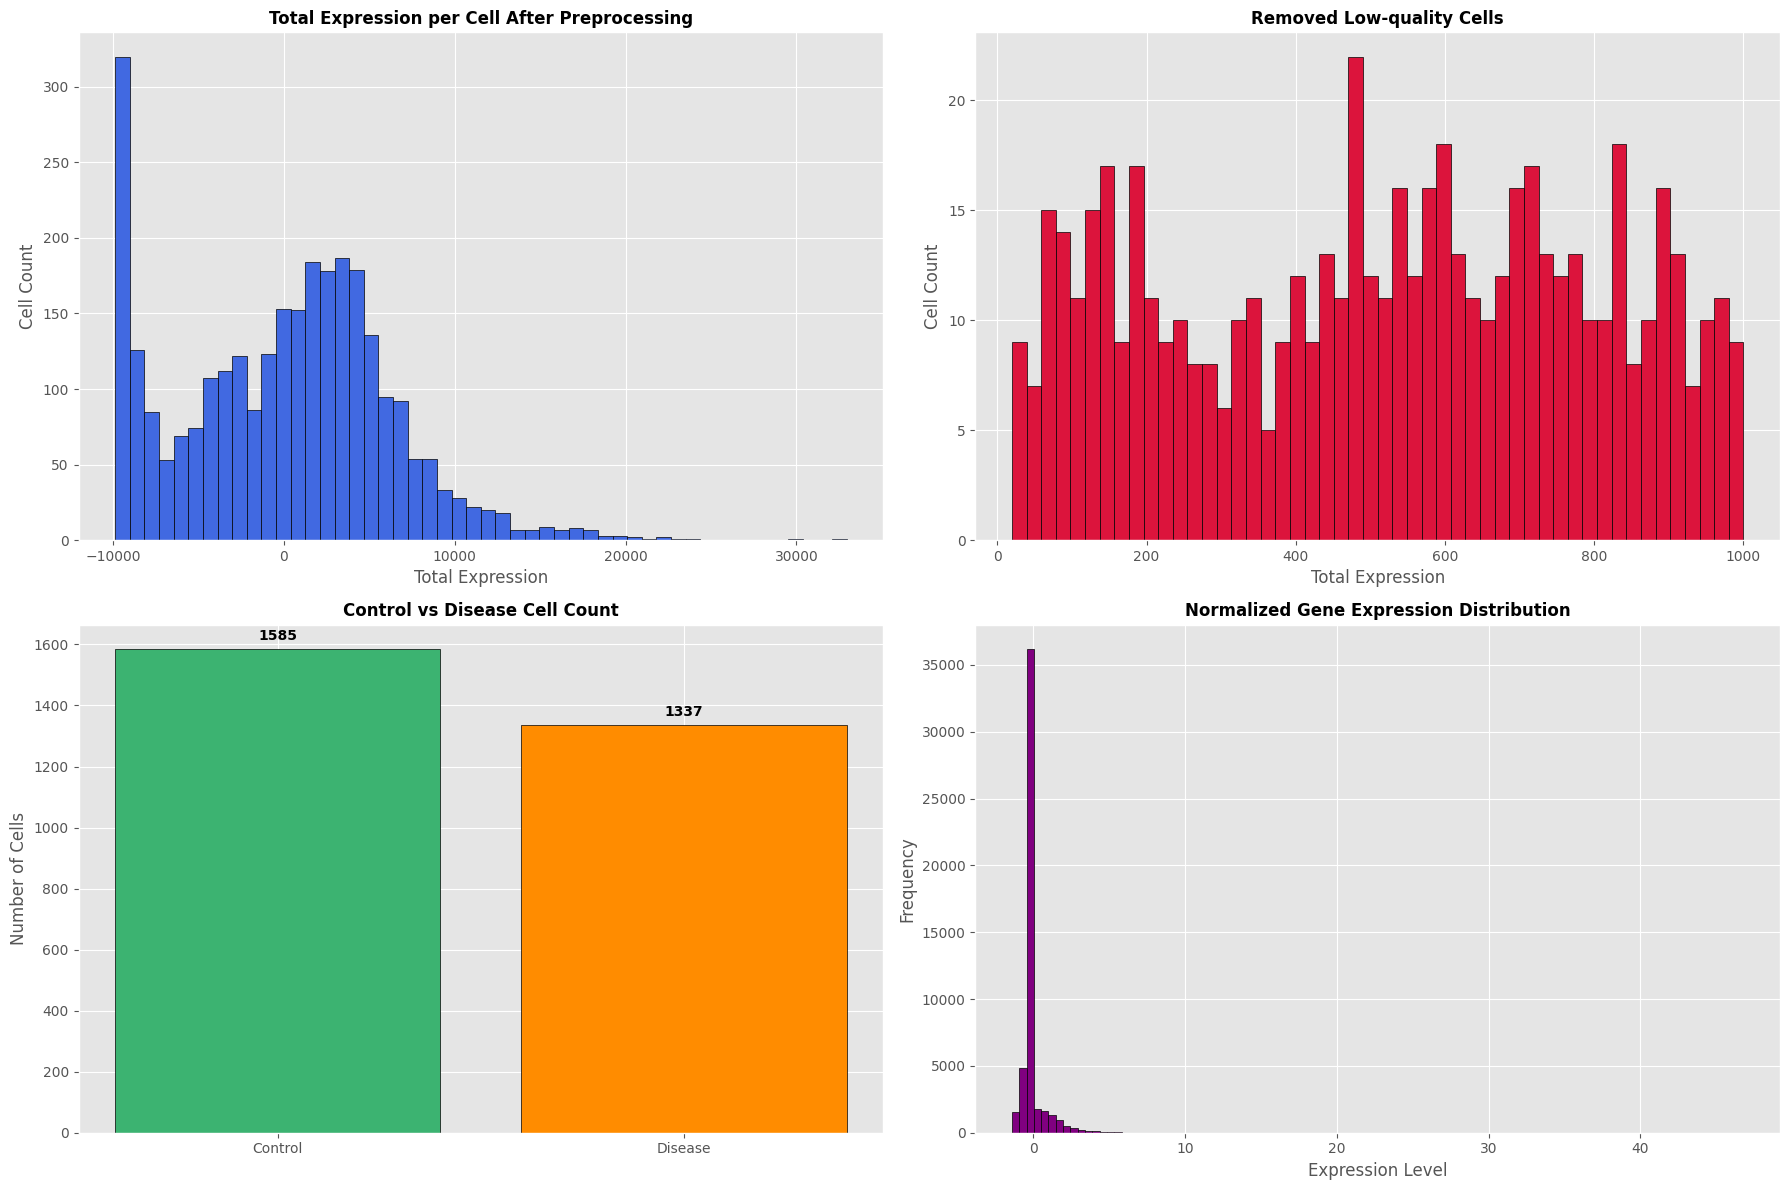

Image saved as: scRNA_preprocessing_summary.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Style
# -------------------------------
plt.style.use("ggplot")


chunksize = 1000

control_file = "scRNA_control_data.csv"
disease_file = "scRNA_disease_data.csv"
removed_file = "removed_low_quality_cells.csv"

# -------------------------------
# Helper function to read chunks
# -------------------------------
def read_chunks(file):
    chunks = []
    for chunk in pd.read_csv(file, index_col=0, chunksize=chunksize):
        chunks.append(chunk)
    return pd.concat(chunks)

# -------------------------------
# Load datasets
# -------------------------------
print("Loading data...")
control_data = read_chunks(control_file)
disease_data = read_chunks(disease_file)
removed_data = read_chunks(removed_file)

# Merge processed data
processed_data = pd.concat([control_data, disease_data], axis=1)

print("Control Shape:", control_data.shape)
print("Disease Shape:", disease_data.shape)
print("Removed Shape:", removed_data.shape)

# -------------------------------
# Prepare data for plots
# -------------------------------

# 1. Cell-wise total expression after preprocessing
cell_sums_after = processed_data.sum(axis=0)

# 2. Removed low-quality cells distribution
cell_sums_removed = removed_data.sum(axis=0)

# 3. Sample normalized expression values
sample_values = []
num_rows = processed_data.shape[0]
row_chunk_size = max(1, num_rows // 10)

for i in range(0, num_rows, row_chunk_size):
    chunk = processed_data.iloc[i:i+row_chunk_size]
    sample_values.extend(chunk.values.flatten()[:5000])

# -------------------------------
# Create one figure with 4 plots
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# -------------------------------
# Plot 1
# -------------------------------
axes[0, 0].hist(cell_sums_after, bins=50, color="royalblue", edgecolor="black")
axes[0, 0].set_title("Total Expression per Cell After Preprocessing", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Total Expression")
axes[0, 0].set_ylabel("Cell Count")

# -------------------------------
# Plot 2
# -------------------------------
axes[0, 1].hist(cell_sums_removed, bins=50, color="crimson", edgecolor="black")
axes[0, 1].set_title("Removed Low-quality Cells", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Total Expression")
axes[0, 1].set_ylabel("Cell Count")

# -------------------------------
# Plot 3
# -------------------------------
labels = ["Control", "Disease"]
counts = [control_data.shape[1], disease_data.shape[1]]
colors = ["mediumseagreen", "darkorange"]

bars = axes[1, 0].bar(labels, counts, color=colors, edgecolor="black")
axes[1, 0].set_title("Control vs Disease Cell Count", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Number of Cells")

# Add count labels
for bar in bars:
    yval = bar.get_height()
    axes[1, 0].text(
        bar.get_x() + bar.get_width()/2,
        yval + 20,
        int(yval),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight="bold"
    )

# -------------------------------
# Plot 4
# -------------------------------
axes[1, 1].hist(sample_values, bins=100, color="purple", edgecolor="black")
axes[1, 1].set_title("Normalized Gene Expression Distribution", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Expression Level")
axes[1, 1].set_ylabel("Frequency")

# -------------------------------
# Final layout and save
# -------------------------------
plt.tight_layout()
plt.savefig("scRNA_preprocessing_summary.png", dpi=300)
plt.show()

print("Image saved as: scRNA_preprocessing_summary.png")

In [3]:
import pandas as pd

chunksize = 1000

# -------------------------------
# Read Control Data in chunks
# -------------------------------
control_chunks = []
for chunk in pd.read_csv("scRNA_control_data.csv", index_col=0, chunksize=chunksize):
    control_chunks.append(chunk)

control_data = pd.concat(control_chunks)

print("\nControl Data Preview:")
control_data.head(10)


Control Data Preview:


,HP1502401_F14,HP1502401_J13,HP1502401_B13,HP1502401_H13,HP1502401_J14,HP1502401_B14,HP1502401_A14,HP1502401_C14,HP1502401_G14,HP1502401_E14,...,HP1504901_N4,HP1504901_E2,HP1504901_D21,HP1504901_G19,HP1504901_C22,HP1504901_N21,HP1504901_B2,HP1504901_L9,HP1504901_N23,HP1504901_F3
#samples,,,,,,,,,,,,,,,,,,,,,
0.000000,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,4.229839,...,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217
14.671218,-0.363672,-0.363672,-0.363672,1.134352,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,...,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672
1.740429,-0.597224,-0.597224,-0.597224,-0.597224,-0.597224,-0.597224,1.156231,-0.148413,-0.597224,-0.597224,...,-0.597224,3.577389,-0.148413,-0.148413,-0.597224,3.013188,-0.597224,-0.597224,-0.597224,1.486990
0.000000,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,2.247115,-0.267486,...,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,0.705294,0.705294,-0.267486,-0.267486
22.250055,-0.767685,-0.767685,-0.767685,-0.343145,-0.767685,0.700982,1.675495,-0.767685,-0.767685,2.213591,...,-0.767685,-0.767685,-0.767685,1.652380,-0.767685,-0.767685,-0.767685,-0.767685,-0.767685,-0.767685
3.053843,-0.309480,-0.309480,-0.309480,3.011670,-0.309480,4.686976,-0.309480,-0.309480,4.200237,-0.309480,...,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480
0.000000,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,2.312347,-0.395871,...,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871
0.000000,-0.576353,-0.576353,-0.576353,-0.576353,-0.576353,-0.576353,-0.576353,1.452308,1.068312,-0.576353,...,-0.576353,-0.576353,-0.576353,-0.028131,-0.576353,-0.576353,-0.576353,-0.576353,1.616534,-0.576353
97.480468,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,...,-0.748179,2.452383,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179


In [4]:
print("Control Data Shape:", control_data.shape)

Control Data Shape: (21560, 1585)


In [5]:
import pandas as pd

chunksize = 1000
# -------------------------------
# Read Disease Data in chunks
# -------------------------------
disease_chunks = []
for chunk in pd.read_csv("scRNA_disease_data.csv", index_col=0, chunksize=chunksize):
    disease_chunks.append(chunk)

disease_data = pd.concat(disease_chunks)
print("\ndisease Data Preview:")
disease_data.head(10)


disease Data Preview:


,HP1504101T2D_I3,HP1504101T2D_D16,HP1504101T2D_D22,HP1504101T2D_B4,HP1504101T2D_M6,HP1504101T2D_F15,HP1504101T2D_H7,HP1504101T2D_F8,HP1504101T2D_F10,HP1504101T2D_B10,...,HP1526901T2D_N16,HP1526901T2D_C8,HP1525301T2D_O10,HP1526901T2D_H2,HP1526901T2D_I16,HP1526901T2D_F7,HP1525301T2D_K3,HP1525301T2D_J10,HP1526901T2D_N8,HP1526901T2D_A8
#samples,,,,,,,,,,,,,,,,,,,,,
0.000000,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,...,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,3.042716,2.302503,-0.232217,-0.232217,-0.232217
14.671218,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,4.078524,-0.363672,-0.363672,-0.363672,-0.363672,...,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,2.697888,-0.363672,-0.363672,-0.363672,1.375481
1.740429,-0.597224,-0.597224,-0.597224,-0.597224,-0.597224,-0.597224,3.865085,-0.148413,2.009181,-0.597224,...,-0.597224,0.444883,0.114125,1.374096,2.105681,1.309292,-0.597224,-0.597224,-0.597224,-0.148413
0.000000,-0.267486,-0.267486,-0.267486,5.478622,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,3.219895,...,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,2.247115,-0.267486,-0.267486
22.250055,-0.767685,-0.767685,-0.767685,0.642606,-0.767685,0.505935,-0.767685,-0.767685,-0.767685,1.152748,...,-0.767685,0.754275,-0.767685,-0.767685,-0.767685,0.890946,-0.343145,1.603355,0.505935,0.424149
3.053843,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480,3.327939,-0.309480,-0.309480,-0.309480,-0.309480,...,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480,-0.309480,0.562818,-0.309480,0.562818
0.000000,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,...,0.506869,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871,-0.395871
0.000000,0.292558,-0.576353,-0.576353,-0.576353,0.840779,2.257912,-0.028131,-0.576353,-0.576353,-0.576353,...,2.434400,-0.576353,-0.576353,-0.576353,-0.576353,-0.576353,-0.576353,-0.576353,0.696578,-0.576353
97.480468,-0.748179,-0.748179,-0.748179,0.925685,0.375298,-0.748179,-0.748179,-0.748179,-0.748179,-0.748179,...,-0.264324,0.986424,-0.748179,-0.748179,0.859153,1.440570,1.809190,-0.748179,0.018713,1.692577


In [5]:
print("\nDisease Data Preview:")
disease_data.head()


Disease Data Preview:


,HP1504101T2D_I3,HP1504101T2D_D16,HP1504101T2D_D22,HP1504101T2D_B4,HP1504101T2D_M6,HP1504101T2D_F15,HP1504101T2D_H7,HP1504101T2D_F8,HP1504101T2D_F10,HP1504101T2D_B10,...,HP1526901T2D_N16,HP1526901T2D_C8,HP1525301T2D_O10,HP1526901T2D_H2,HP1526901T2D_I16,HP1526901T2D_F7,HP1525301T2D_K3,HP1525301T2D_J10,HP1526901T2D_N8,HP1526901T2D_A8
#samples,,,,,,,,,,,,,,,,,,,,,
0.000000,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,...,-0.232217,-0.232217,-0.232217,-0.232217,-0.232217,3.042716,2.302503,-0.232217,-0.232217,-0.232217
14.671218,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,4.078524,-0.363672,-0.363672,-0.363672,-0.363672,...,-0.363672,-0.363672,-0.363672,-0.363672,-0.363672,2.697888,-0.363672,-0.363672,-0.363672,1.375481
1.740429,-0.597224,-0.597224,-0.597224,-0.597224,-0.597224,-0.597224,3.865085,-0.148413,2.009181,-0.597224,...,-0.597224,0.444883,0.114125,1.374096,2.105681,1.309292,-0.597224,-0.597224,-0.597224,-0.148413
0.000000,-0.267486,-0.267486,-0.267486,5.478622,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,3.219895,...,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,-0.267486,2.247115,-0.267486,-0.267486
22.250055,-0.767685,-0.767685,-0.767685,0.642606,-0.767685,0.505935,-0.767685,-0.767685,-0.767685,1.152748,...,-0.767685,0.754275,-0.767685,-0.767685,-0.767685,0.890946,-0.343145,1.603355,0.505935,0.424149


In [6]:
print("Disease Data Shape:", disease_data.shape)

Disease Data Shape: (21560, 1337)


In [1]:
#Removed Low Quality cells

In [7]:
import pandas as pd
removed_chunks = pd.read_csv("removed_low_quality_cells.csv", chunksize=1000)

removed_list = []

for chunk in removed_chunks:
    removed_list.append(chunk)

removed_df = pd.concat(removed_list, ignore_index=True)

removed_df.head()


,Gene,HP1502401_N13,HP1502401_D14,HP1502401_B19,HP1504101T2D_B2,HP1504101T2D_L6,HP1502401_A11,HP1502401_B3,HP1502401_C11,HP1504101T2D_E5,...,HP1525301T2D_J6,HP1525301T2D_E10,HP1525301T2D_G7,HP1525301T2D_E18,HP1525301T2D_O19,HP1526901T2D_H15,HP1526901T2D_C18,HP1525301T2D_L18,HP1526901T2D_I23,HP1526901T2D_O11
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,14.671218,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.740429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,22.250055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
print(removed_df.shape)

(21560, 593)


In [8]:
#Description 

# Why were these cells removed?
  # Too many zero values (low expression cells)
  #     Many cells in your data show 0 expression for most genes
  #     This means:
  #     The cell is likely dead / damaged / empty droplet
  #     These cells don’t give useful biological information

  # Low gene detection
  #     Typical rule:
  #     Remove cells that express very few genes

  # Low total counts (library size)
  #     If a cell has very low total expression

  # High mitochondrial gene expression (if checked)
  #     (Not visible in your sample, but common)
  #     High % mitochondrial genes =
  #     Cell is stressed or dying

  # Doublets / outliers
  #       Some cells behave abnormally (too high expression)
  #       Could be:
  #       Two cells captured together
  #       Experimental errors
          

In [ ]:
# Why removing these cells is IMPORTANT

  # 1. Improves accuracy
  #    Bad cells = noise → wrong biological conclusions

  # 2. Better clustering & analysis
  #   In your research (T2D multi-omics):
  #   Clean data → better cell grouping
  #   Better biomarker detection

  # 3. Prevents false biomarkers
  #   Without filtering:
  #   You might detect genes as “important” just due to noise

  # 4. Essential for downstream steps
  #   You’ll later do:
  #       Normalization
  #       DEG analysis
  #       PPI networkaccuracy
